# (Complex-Scaled) Restricted Hartree Fock
This notebook serves as a brief guide of the results obtained, explanation of the use and so on. We use these external libraries:

In [1]:
import numpy as np 
from pathlib import Path
import matplotlib.pyplot as plt 
from pyscf import gto, scf

## RHF implementation
RHF has been implemented as sen in Szabo. Currently the RHF routine requires to input the value of molecular integrals: $T$, $V$, $S$, and $(ij|kl)$. The implementation can be easily compared with known results as the $H_2$ example in Szabo and the one obtained using using Pyscf. In the $H_2$ case, the total HF energy obtained for two $H$ atoms separated 1.4 atomic units is:
$$
E_{HF}^{sto3g} = -1.1167
$$
Inclyding the $V_{NN}$ terms. The same calculation using Pyscf can be performed as:

In [2]:
dist = 1.4 * 0.529177249

mol_H2 = gto.M(atom = f'H 0 0 0; H 0 0 {dist}', spin=0)

T_sto3g_H2 = mol_H2.intor('int1e_kin')
V_sto3g_H2 = mol_H2.intor('int1e_nuc')
S_sto3g_H2 = mol_H2.intor('int1e_ovlp')
eri_sto3g_H2 = mol_H2.intor('int2e')

rhf_H2 = scf.RHF(mol_H2)

pyscf_e_H2 = rhf_H2.kernel()
e_elec = rhf_H2.energy_elec()

print(f"H2 energy calculated by pyscf = {pyscf_e_H2}")

converged SCF energy = -1.11671432219594
H2 energy calculated by pyscf = -1.1167143221959424


Where we can see that the result is the expected one. Using the implementation of RHF, the electronic energy obtained is: 

In [3]:
from py_mods.src.RHF import RHF
from py_mods.src.scf_utils import V_NN

positions = np.array([
    [0. , 0. , 0. ],
    [0. , 0. , 1.4]
])

nuc_nuc = V_NN(positions, np.array([1,1]), units='Bohr')

# test : SCF convergence for H2 in STO-3G
converged, E_elec, E_e_values, C_munu, P = RHF(S_sto3g_H2, T_sto3g_H2, V_sto3g_H2, eri_sto3g_H2, n_electrons=2, max_iter=100, threshold=1E-14, p_guess='core', verbose=True)


----------------------------------------------------------------------
|   Iter   |           E_iter           |            Delta_e         |
----------------------------------------------------------------------
    0           -2.5055940592310546           -2.5055940592310546
    1           -1.8309999850811094            0.6745940741499452
    2           -1.8309999850811094            0.6745940741499452
Convergence achieved after 2 iterations. Final SCF energy = -1.8309999850811094


And adding the $V_{NN}$ term:


In [4]:
total_energy = E_elec + nuc_nuc
print(f'Total energy = {total_energy}')
print(f'Total_energy - pyscf_reference = {total_energy-pyscf_e_H2}')

Total energy = -1.116714270795395
Total_energy - pyscf_reference = 5.1400547373958716e-08


Which is the same up to a certain numerical aspect, which corresponds to $V_{NN}$ as we will see now with the next example. Since Complex scaling has to be done in atoms due to the non dilation-analicity of the coulomb potential in molecules, let's see the case of He: 

In [5]:
mol_He = gto.M(atom = 'He 0 0 0', spin=0, charge=0, basis='aug-ccpvqz')

T_sto3g_He = mol_He.intor('int1e_kin')
V_sto3g_He = mol_He.intor('int1e_nuc')
S_sto3g_He = mol_He.intor('int1e_ovlp')
eri_sto3g_He = mol_He.intor('int2e')

rhf_He = scf.RHF(mol_He)
# rhf_He.init_guess = 'hcore'
# rhf_He.max_cycle = 0

pyscf_e_He = rhf_He.kernel()
e_elec = rhf_He.energy_elec()

print(f"H2 energy calculated by pyscf = {pyscf_e_He}")

converged SCF energy = -2.86152199563245
H2 energy calculated by pyscf = -2.861521995632452


In [6]:
converged, E_elec, E_e_values, C_munu, P = RHF(S_sto3g_He, T_sto3g_He, V_sto3g_He, eri_sto3g_He, n_electrons=2, max_iter=100, threshold=1E-14, p_guess='core', verbose=True)

----------------------------------------------------------------------
|   Iter   |           E_iter           |            Delta_e         |
----------------------------------------------------------------------
    0           -3.9996224179871307           -3.9996224179871307
    1           -2.7547092304134289            1.2449131875737018
    2           -2.8509905894254222           -0.0962813590119933
    3           -2.8601932014383693           -0.0092026120129471
    4           -2.8613136524750282           -0.0011204510366589
    5           -2.8614841942619509           -0.0001705417869227
    6           -2.8615145672508779           -0.0000303729889271
    7           -2.8615204727233481           -0.0000059054724701
    8           -2.8615216758299633           -0.0000012031066152
    9           -2.8615219274636479           -0.0000002516336846
   10           -2.8615219809542469           -0.0000000534905991
   11           -2.8615219924491764           -0.000000011494

And the difference:

In [7]:
total_energy = E_elec 
print(f'Total energy = {total_energy}')
print(f'Total_energy - pyscf_reference = {total_energy-pyscf_e_He}')

Total energy = -2.861521995632469
Total_energy - pyscf_reference = -1.7319479184152442e-14


Which shows that the source of error in the $H_2$ molecule was the $V_{NN}$ term. 

# Complex scaled RHF

## He 1s2 
In the case of CS RHF, the Haniltionian components are scaled by a term:
$$
\hat{S} = e ^{-i\theta \frac{\partial \hat{O}}{\partial r}}
$$

Which makes the total Hamiltonian to be: 
$$
\mathbf{H}_{\mu \nu}(\theta) = e^{ -2i\theta }\mathbf{T}_{\mu \nu} + e^{ -i\theta }\mathbf{V}_{\mu \nu} + e^{ -i\theta }\mathbf{(ij|kl)}
$$

Also, the definition of the denisty matrix cannot be done directly as in the non-scaled case, due to the Hamiltonian not being Hermitian. Therefore, it is necessary to define left and right solutions (and thus MO coefficitents). This way, the Density matrix is defined as:
$$
\mathbf{P_{\mu \nu}}=2\sum_{a}^{N/2}L_{\nu a}R_{\mu a}
$$

And the two-electron component matrix elements:
$$
\mathbf{G_{\mu \nu}} = e^{ -i\theta }

\sum_{\lambda \sigma} \mathbf{P}_{\lambda \sigma}\left[ (\mu \nu|\sigma \lambda)- \frac{1}{2} (\mu \lambda|\sigma \nu) \right]
$$

The left and soultions can be obtained in the orthogonalized representation by inverting the eigenvector matrix obtained from the diagonalization. Then it can be transformed to the non-orthogonal representation by:
$$
\mathbf{L}_{\nu \mu} = \mathbf{L_{\mu \nu}'X_{\mu \nu}}
$$

However, in the case of $\theta = 0$, the results should be exactly the same as in the non-scaled RHF, but now wit a zero imaginary component. We are going to use even-tempered basis defined from:

Where the parameters $\alpha_0$ and $\varepsilon$ were obtained from [https://www.basissetexchange.org/](https://www.basissetexchange.org/):
```
#   Basis set: UGBS
# Description: Universal Gaussian Basis Set
#        Role: orbital
#     Version: 0  (Data from the Original Basis Set Exchange)
```

We defined a function to calculate an even tempered basis and fed it to pyscf to compute the integrals. 

In [8]:
from py_mods.src.basis_utils import even_temp_uncontr_str

He_tempered_str = even_temp_uncontr_str('He', 'S', 7.668876968794860E-002, 1.9581497063588078, 29)

mol_He= gto.M(atom = 'He 0 0 0', spin=0, charge=0, basis='aug-cc-pvqz')
mol_He.basis = {'He': gto.basis.parse(He_tempered_str)}
mol_He.build()

kin = mol_He.intor('int1e_kin')
vnuc = mol_He.intor('int1e_nuc')
overlap = mol_He.intor('int1e_ovlp')
eri = mol_He.intor('int2e')

rhf_He = scf.RHF(mol_He)
e_He = rhf_He.kernel()

print(f"He energy calculated by pyscf = {pyscf_e_He}")

-2.568 0.672000000000001
converged SCF energy = -2.86167999300153
He energy calculated by pyscf = -2.861521995632452


And now with the CSRHF routine using $\theta=0$:

In [9]:
from dev.CSUHF_dev import CS_RHF, plot_theta_orbital_energies
nelec = 2
theta = 0.0

# even_tempered_demonstration(7.668876968794860E-002, 1.9581497063588078, 29)

converged, E_elec_comp, E_e_values, C_munu, P = CS_RHF(overlap, kin, vnuc, eri, nelec, theta, max_iter=500, threshold=1E-12, p_guess='core', verbose=True)


-----------------------------------------------------------------------------------------------
|   Iter   |               E_iter                  |                   Delta_e                |
-----------------------------------------------------------------------------------------------
    0     -3.9999999905051182+0.0000000000000000j     -3.9999999905051182+0.0000000000000000j
    1     -2.7546351175227120+0.0000000000000000j     1.2453648729824063+0.0000000000000000j
    2     -2.8511694661202132+0.0000000000000000j     -0.0965343485975012+0.0000000000000000j
    3     -2.8603533202301801+0.0000000000000000j     -0.0091838541099669+0.0000000000000000j
    4     -2.8614712715208346+0.0000000000000000j     -0.0011179512906545+0.0000000000000000j
    5     -2.8616419184988668+0.0000000000000000j     -0.0001706469780323+0.0000000000000000j
    6     -2.8616724454248552+0.0000000000000000j     -0.0000305269259884+0.0000000000000000j
    7     -2.8616784257038330+0.0000000000000000j     -

In [10]:
converged, E_elec, E_e_values, C_munu, P = RHF(overlap, kin, vnuc, eri, nelec, max_iter=100, threshold=1E-12, p_guess='core', verbose=False)
print(f'Pyscf energy obtained = {e_He}')
print(f'Comparison between unscaled CSRHF and pyscf routines: {E_elec_comp - e_He}')
print(f'Comparison between unscaled CSRHF and RHF routines: {E_elec_comp - E_elec}')

Pyscf energy obtained = -2.8616799930015295
Comparison between unscaled CSRHF and pyscf routines: (4.574118861455645e-14+0j)
Comparison between unscaled CSRHF and RHF routines: (1.7763568394002505e-15+0j)


Which shows that the implementation of the biorthogonal solutions works. Now testing with a different value of $\theta$, We can see the orbital enegies under rotation with:

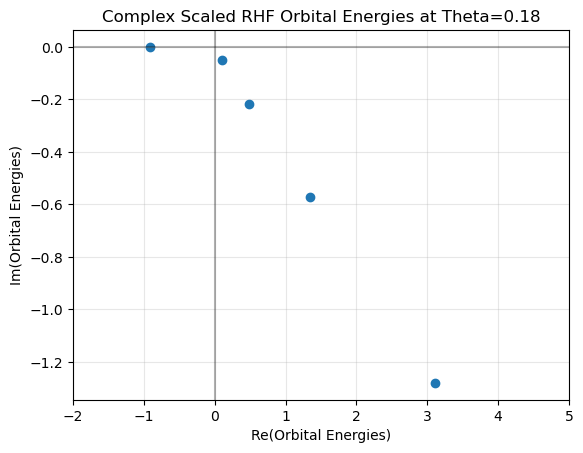

In [11]:
nelec = 2
theta = 0.18

# even_tempered_demonstration(7.668876968794860E-002, 1.9581497063588078, 29)

converged, E_elec_comp, E_e_values, C_munu, P = CS_RHF(overlap, kin, vnuc, eri, nelec, theta, max_iter=500, threshold=1E-12, p_guess='core', verbose=False)
plot_theta_orbital_energies(E_e_values, theta, [-2,5])


Now we can calculate theta trajectories with:

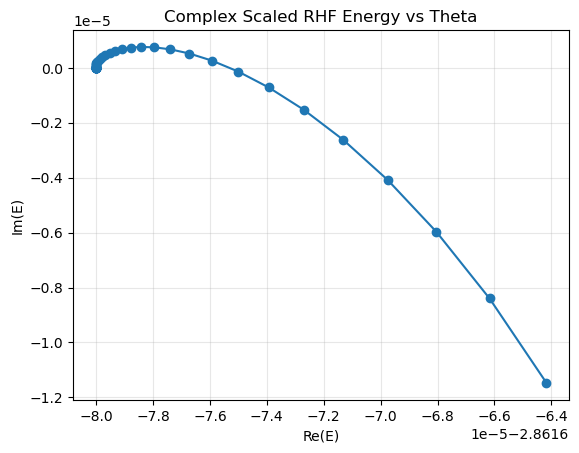

In [12]:
from dev.CSUHF_dev import theta_traj, plot_theta_traj

max_theta = 0.5
n_points = 50

traj_energies = theta_traj(max_theta, n_points, overlap, kin, vnuc, eri, nelec, theta, max_iter=100, threshold=1E-12, p_guess='core', verbose=False)
plot_theta_traj(traj_energies[1]) 

Showing that there is a variation of the imaginary component when changing the $\theta$ value. However there is a positive value of the imaginary component of up to $7.631\cdot 10^ {-7}$:

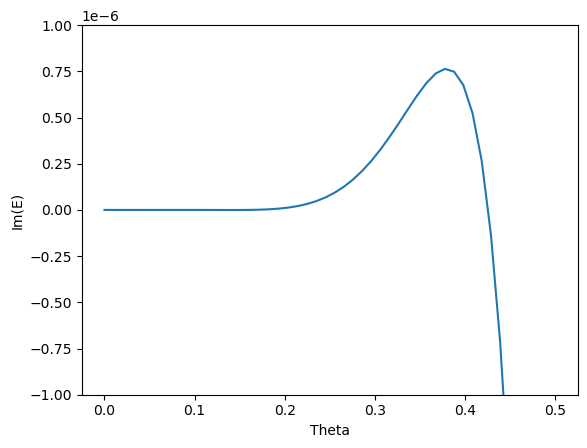

In [13]:
plt.plot(traj_energies[0], [ener.imag for ener in traj_energies[1]])
plt.xlabel('Theta')
plt.ylabel('Im(E)')
plt.ylim([-1E-6, 1E-6])
plt.show()